# 💘 Decoding Attraction: What Really Predicts a Speed-Dating Match?

### A rigorous, leakage-aware look at 14,504 speed dates

---

**TL;DR** — Two people match only if *both* independently say "yes." That single fact turns out to be the
most important thing in this whole notebook: it creates a **perfect, deterministic leakage column**
that will silently give you 100% accuracy if you're not careful. Half of this notebook is about the
*interesting, honest* machine-learning problem hiding behind that trap.

## What is this dataset?

Each row is one **speed date** between one man and one woman at a structured speed-dating event.
After a few minutes of conversation, each person privately decides `1` (yes, I'd like to see them again)
or `0` (no). We also know how each person *rated* their partner (attractiveness, sincerity, intelligence,
fun, ambition), how much each person says they *value* those traits, some demographics, and how socially
active each person is (`goes_out`).

`match = 1` only when **both** people say yes.

## Why does this matter?

Speed dating is a clean micro-laboratory for a question that matters far beyond the dataset: *what
actually predicts mutual interest between two people, and how much of it is about you, about them, or
about the fit between you?* It's also a great sandbox for practicing two skills that separate a solid
data scientist from a great one:

1. **Spotting leakage before it flatters you.** A model that "predicts" `match` using each person's own
   decision isn't predicting anything — it's just doing boolean algebra.
2. **Reframing the problem to match how it would actually be used.** In the real world, you don't get to
   see whether your date said yes before deciding whether *you* say yes. A more honest and more useful
   model predicts each side's decision independently, *then* derives the match probability.

## Roadmap

1. [Data Understanding](#data-understanding)
2. [Exploratory Data Analysis](#eda)
3. [⚠️ The Leakage Trap](#leakage-trap)
4. [Data Cleaning & Preprocessing](#cleaning)
5. [Feature Engineering](#feature-engineering)
6. [Modeling Strategy](#modeling)
7. [Evaluation](#evaluation)
8. [Hyperparameter Optimization](#optimization)
9. [Interpretability (Importance + SHAP)](#interpretability)
10. [Beyond "Match": Two-Stage Decision Modeling](#two-stage)
11. [Error Analysis](#error-analysis)
12. [What Surprised Us in This Dataset?](#surprises)
13. [Key Findings & Conclusion](#conclusion)


In [1]:
# ------------------------------------------------------------------
# Setup
# ------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import GroupKFold, RandomizedSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                              roc_curve, precision_recall_curve, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve

import xgboost as xgb
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Professional plotting defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (9, 5.5),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
sns.set_palette(PALETTE)

print("Environment ready.")


Environment ready.


<a id="data-understanding"></a>
## 1. Data Understanding

Before drawing a single conclusion, let's get to know the dataset on its own terms: its shape, its
types, its missingness, and — critically — what each column actually *means*. Speed-dating data is full
of columns that sound similar but are conceptually very different (e.g. "how much I say I value
attractiveness" vs. "how attractive I actually rated my partner"), so mixing them up is an easy way to
build a model that looks smart but is measuring the wrong thing.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/sergionefedov/speed-dating-and-attraction-outcomes/speed_dating_master.csv')
data_dict = pd.read_csv('/kaggle/input/datasets/sergionefedov/speed-dating-and-attraction-outcomes/data_dictionary.csv')

print(f"Shape: {df.shape[0]:,} dates  x  {df.shape[1]} columns")
df.head()


Shape: 14,504 dates  x  30 columns


,event_id,male_id,female_id,male_age,female_age,age_gap,same_race,same_field,shared_interests,attr_of_female,...,male_pref_intel,female_pref_attr,female_pref_intel,male_self_attr,female_self_attr,male_goes_out,female_goes_out,male_decision,female_decision,match
0,0,P00000,P00006,28,29,1,0,0,5.3,2.6,...,18.3,14.9,23.6,8.4,5.0,often,very_often,0,0,0
1,0,P00000,P00007,28,26,2,0,0,9.0,8.0,...,18.3,35.6,16.5,8.4,6.2,often,rarely,1,1,1
2,0,P00000,P00008,28,32,4,0,0,2.6,5.0,...,18.3,35.6,17.8,8.4,4.9,often,very_often,0,1,0
3,0,P00000,P00009,28,22,6,0,1,2.8,3.3,...,18.3,14.9,22.3,8.4,6.4,often,often,0,1,0
4,0,P00000,P00010,28,27,1,0,0,3.4,5.3,...,18.3,30.9,16.1,8.4,4.4,often,rarely,0,1,0


In [3]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().mean()*100).round(2),
    'n_unique': df.nunique()
})
summary


,dtype,n_missing,pct_missing,n_unique
event_id,int64,0,0.0,120
male_id,object,0,0.0,1274
female_id,object,0,0.0,1274
male_age,int64,0,0.0,24
female_age,int64,0,0.0,26
age_gap,int64,0,0.0,26
same_race,int64,0,0.0,2
same_field,int64,0,0.0,2
shared_interests,float64,0,0.0,101
attr_of_female,float64,0,0.0,91


In [4]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Unique events: {df['event_id'].nunique()}")
print(f"Unique men: {df['male_id'].nunique()}   Unique women: {df['female_id'].nunique()}")
print(f"Dates per event -> min: {df.groupby('event_id').size().min()}, "
      f"median: {int(df.groupby('event_id').size().median())}, "
      f"max: {df.groupby('event_id').size().max()}")

# Does any man/woman appear across more than one event?
spans_multiple_male = (df.groupby('male_id')['event_id'].nunique() > 1).sum()
spans_multiple_female = (df.groupby('female_id')['event_id'].nunique() > 1).sum()
print(f"Men appearing in >1 event: {spans_multiple_male}  |  Women appearing in >1 event: {spans_multiple_female}")


Duplicate rows: 0
Unique events: 120
Unique men: 1274   Unique women: 1274
Dates per event -> min: 36, median: 121, max: 225
Men appearing in >1 event: 0  |  Women appearing in >1 event: 0


**Data quality observations**

- **No missing values, no duplicate rows.** This is unusually clean for speed-dating data — the
  well-known real-world speed-dating studies this kind of dataset is modeled after are notoriously messy
  (missing surveys, inconsistent scales, dropped waves). That's worth remembering when we get to the
  *Limitations* section: results here will look cleaner than a messier real-world version would.
- **Every person appears in exactly one event.** This matters enormously for how we split data for
  modeling (Section 4) — if we split rows randomly, the *same person* could appear in both the training
  and validation sets under a different partner, letting the model partially "memorize" that person
  rather than learn generalizable patterns. Because people never cross events, **splitting by `event_id`
  is equivalent to splitting by person** — a clean, leak-free grouping variable.
- **120 events, ~120 dates each on average, 1,274 unique men and 1,274 unique women.** A balanced,
  fully-crossed design (every attendee of a given gender rotates through every attendee of the other
  gender at their event).
- **Two columns are pre-registered as leakage** by the data dictionary itself: `male_decision` and
  `female_decision`. We'll prove exactly *why* in Section 3, and treat that as a first-class modeling
  decision rather than a footnote.


<a id="eda"></a>
## 2. Exploratory Data Analysis

We'll move from the simplest question ("how rare is a match?") to progressively richer ones: how do
ratings distribute, what correlates with a match, does shared context (age, race, field) matter, and —
the most interesting question in this section — **do people's stated preferences match their revealed
behavior?**


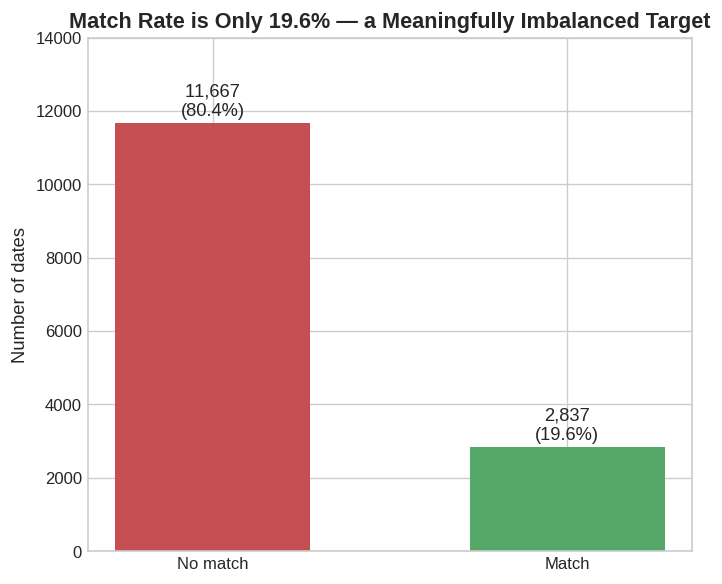

In [5]:
match_rate = df['match'].mean()

fig, ax = plt.subplots(figsize=(6, 5))
counts = df['match'].value_counts().sort_index()
bars = ax.bar(['No match', 'Match'], counts.values, color=[PALETTE[3], PALETTE[2]], width=0.55)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 100, f"{v:,}\n({v/len(df):.1%})",
            ha='center', va='bottom', fontsize=11)
ax.set_title(f"Match Rate is Only {match_rate:.1%} — a Meaningfully Imbalanced Target")
ax.set_ylabel("Number of dates")
ax.set_ylim(0, counts.max()*1.2)
plt.tight_layout()
plt.show()


**Takeaway:** Only **19.6%** of speed dates end in a mutual match. This isn't extreme imbalance, but
it's enough that plain **accuracy would be a misleading metric** — a model that always predicts "no
match" is already 80% "accurate" while being completely useless. We'll standardize on **ROC-AUC**,
**average precision (PR-AUC)**, and **Brier score** (calibration) throughout this notebook instead.


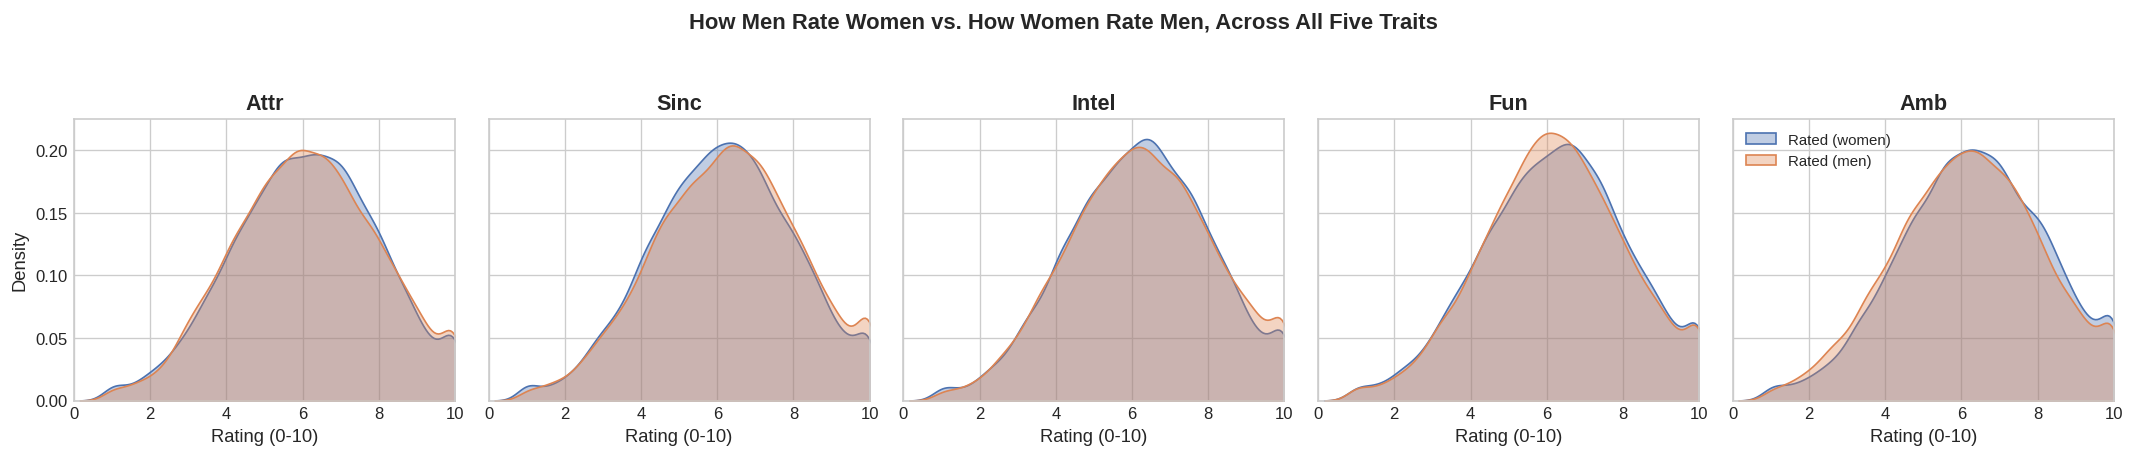

In [6]:
traits = ['attr', 'sinc', 'intel', 'fun', 'amb']
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), sharey=True)
for ax, t in zip(axes, traits):
    sns.kdeplot(df[f'{t}_of_female'], ax=ax, label='Rated (women)', fill=True, alpha=0.35, color=PALETTE[0])
    sns.kdeplot(df[f'{t}_of_male'], ax=ax, label='Rated (men)', fill=True, alpha=0.35, color=PALETTE[1])
    ax.set_title(t.capitalize())
    ax.set_xlabel('Rating (0-10)')
    ax.set_xlim(0, 10)
axes[0].set_ylabel('Density')
axes[-1].legend(loc='upper left', fontsize=9)
fig.suptitle("How Men Rate Women vs. How Women Rate Men, Across All Five Traits", y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()


**Takeaway:** The rating distributions given by men and given by women are nearly identical across
all five traits (means cluster tightly around 6.0–6.3 out of 10, roughly bell-shaped, mild left skew).
There's no strong asymmetry where, say, men rate women systematically higher/lower than women rate men —
the rating *scales* are being used the same way by both genders, which is reassuring for comparing
`_of_male` and `_of_female` columns on equal footing later.


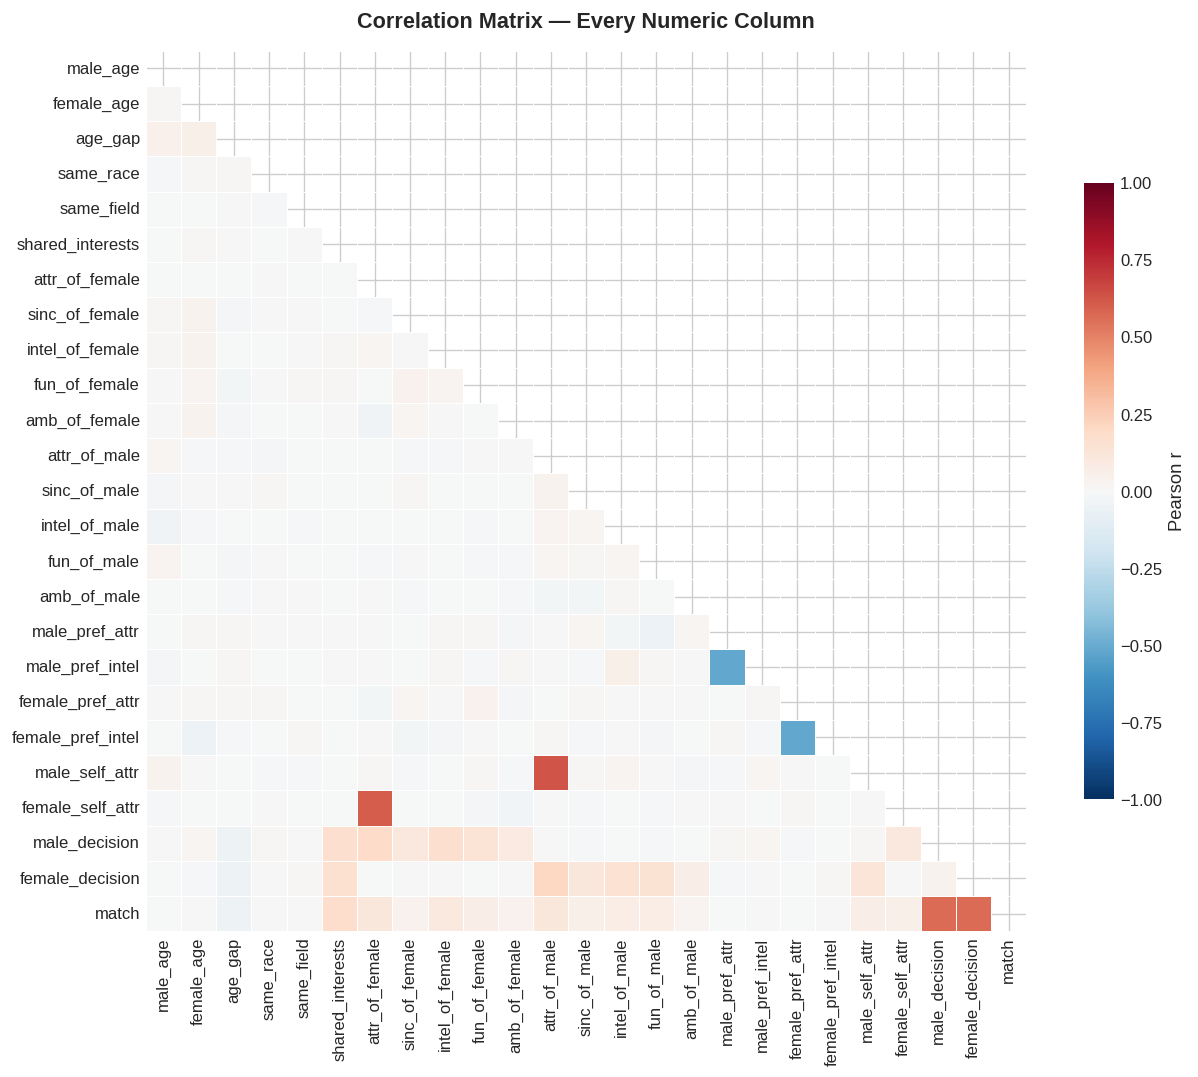

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['event_id'])
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}, ax=ax)
ax.set_title("Correlation Matrix — Every Numeric Column", pad=14)
plt.tight_layout()
plt.show()


**Takeaway (read this one carefully):** `match` correlates at **r ≈ 0.56–0.57** with both
`male_decision` and `female_decision` — far higher than with anything else on the board. That's the
first visual hint of the leakage trap we formalize in Section 3. Beyond that: the five rating traits
(attr/sinc/intel/fun/amb) are all moderately-to-strongly correlated *with each other* within the same
gender (a "halo effect" — people who are rated attractive also tend to get rated as more sincere, fun,
etc.), and `attr_of_*` has the strongest correlation with `match` among the non-decision columns.
`same_race`, `same_field`, and `age_gap` barely register.


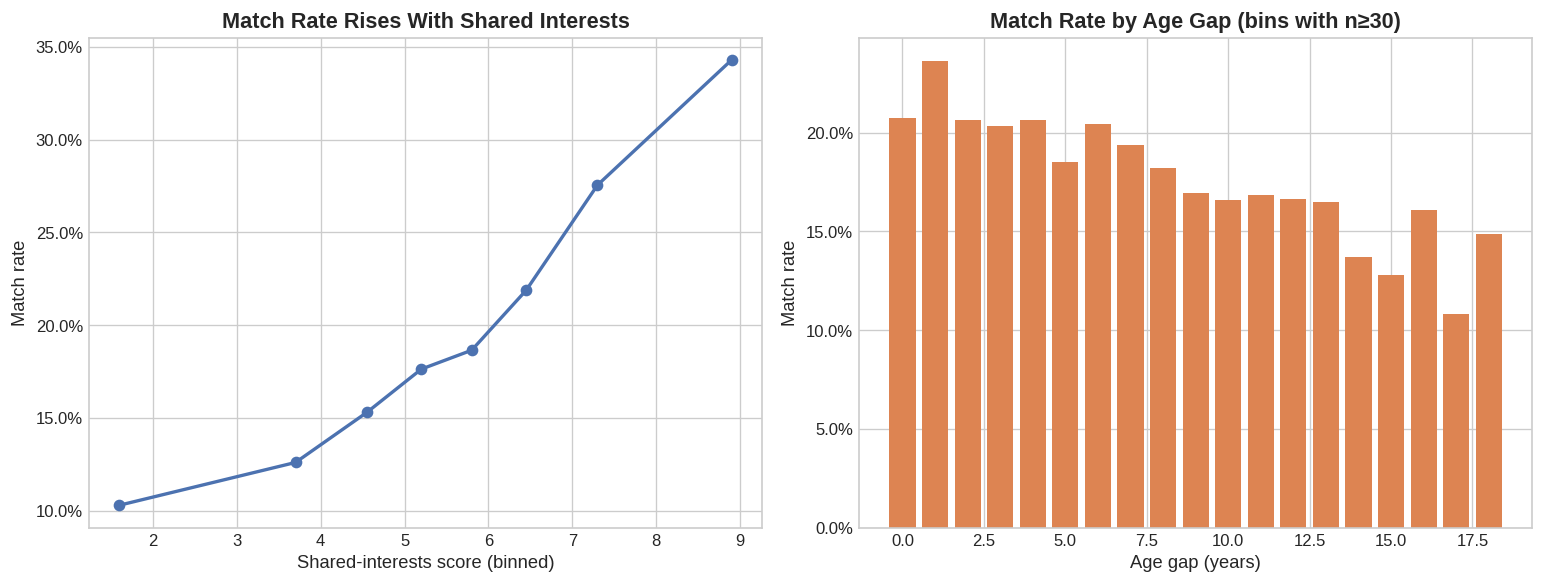

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Match rate by shared_interests decile
df['shared_interests_bin'] = pd.qcut(df['shared_interests'], 8, duplicates='drop')
si_rate = df.groupby('shared_interests_bin', observed=True)['match'].mean()
si_mid = [interval.mid for interval in si_rate.index]
axes[0].plot(si_mid, si_rate.values, marker='o', color=PALETTE[0], linewidth=2)
axes[0].set_title("Match Rate Rises With Shared Interests")
axes[0].set_xlabel("Shared-interests score (binned)")
axes[0].set_ylabel("Match rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Match rate by age gap
ag_rate = df.groupby('age_gap')['match'].mean()
ag_n = df.groupby('age_gap').size()
valid = ag_n[ag_n >= 30].index
axes[1].bar(ag_rate.loc[valid].index, ag_rate.loc[valid].values, color=PALETTE[1])
axes[1].set_title("Match Rate by Age Gap (bins with n≥30)")
axes[1].set_xlabel("Age gap (years)")
axes[1].set_ylabel("Match rate")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()


**Takeaway:** Shared interests show a clean, fairly monotonic relationship with match rate — moving
from the bottom to the top octile roughly doubles the match rate. Age gap shows a mild downward drift
(bigger gap, somewhat lower match rate) but it's noisy and much weaker than shared interests or
attractiveness. Of the "context" variables (age, race, field), **shared interests is the one that
actually earns its keep**.


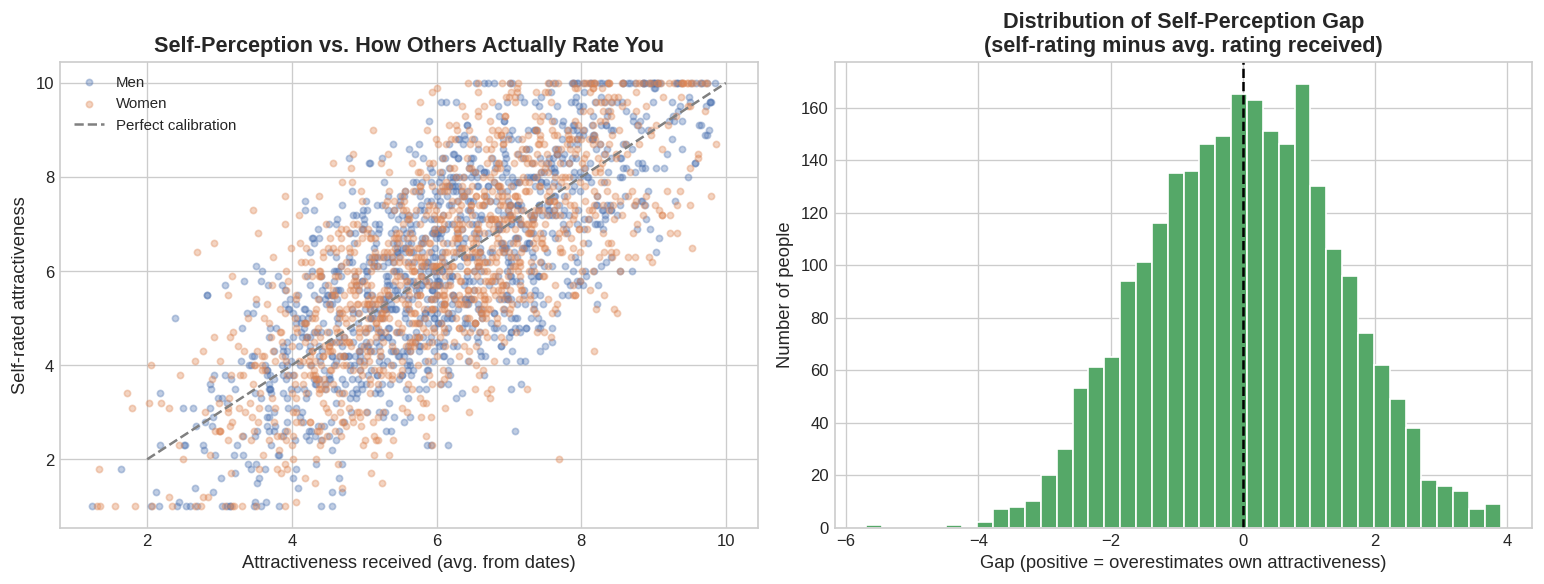

Overestimate their attractiveness (gap > 0.5):  37.4%
Underestimate their attractiveness (gap < -0.5): 36.6%
Reasonably well-calibrated (within +-0.5):       25.9%


In [9]:
# Per-person calibration gap: how you rate yourself vs. how partners rated you, averaged across your dates
male_perceived = df.groupby('male_id')['attr_of_male'].mean()
male_self = df.groupby('male_id')['male_self_attr'].first()
male_gap = (male_self - male_perceived).rename('gap')

female_perceived = df.groupby('female_id')['attr_of_female'].mean()
female_self = df.groupby('female_id')['female_self_attr'].first()
female_gap = (female_self - female_perceived).rename('gap')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(male_perceived, male_self, s=14, alpha=0.35, color=PALETTE[0], label='Men')
axes[0].scatter(female_perceived, female_self, s=14, alpha=0.35, color=PALETTE[1], label='Women')
lims = [2, 10]
axes[0].plot(lims, lims, ls='--', color='gray', linewidth=1.5, label='Perfect calibration')
axes[0].set_xlabel("Attractiveness received (avg. from dates)")
axes[0].set_ylabel("Self-rated attractiveness")
axes[0].set_title("Self-Perception vs. How Others Actually Rate You")
axes[0].legend(fontsize=9)

both_gap = pd.concat([male_gap, female_gap])
axes[1].hist(both_gap, bins=40, color=PALETTE[2], edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title("Distribution of Self-Perception Gap\n(self-rating minus avg. rating received)")
axes[1].set_xlabel("Gap (positive = overestimates own attractiveness)")
axes[1].set_ylabel("Number of people")

plt.tight_layout()
plt.show()

overest = (both_gap > 0.5).mean()
underest = (both_gap < -0.5).mean()
calibrated = 1 - overest - underest
print(f"Overestimate their attractiveness (gap > 0.5):  {overest:.1%}")
print(f"Underestimate their attractiveness (gap < -0.5): {underest:.1%}")
print(f"Reasonably well-calibrated (within +-0.5):       {calibrated:.1%}")


**Takeaway:** At the *population* level, self-rated attractiveness and received attractiveness are
almost perfectly matched on average (~6.1 both ways) — so if you only looked at the means, you'd
conclude "people are well calibrated." But at the **individual** level that's misleading: only about a
quarter of people fall within half a point of perfect calibration, while roughly **37% meaningfully
overestimate** and **37% meaningfully underestimate** their own attractiveness. The averages cancel out;
the individual miscalibration doesn't. This is a good reminder that population-level statistics can hide
substantial individual-level disagreement.


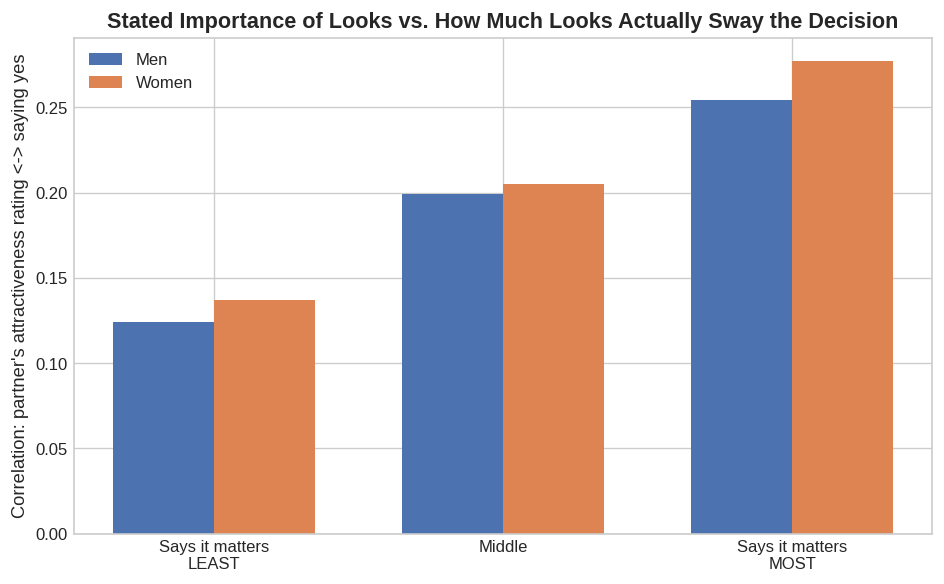

Men   -> correlation by stated-preference tier: {'Says it matters\nLEAST': np.float64(0.124), 'Middle': np.float64(0.199), 'Says it matters\nMOST': np.float64(0.254)}
Women -> correlation by stated-preference tier: {'Says it matters\nLEAST': np.float64(0.137), 'Middle': np.float64(0.205), 'Says it matters\nMOST': np.float64(0.277)}


In [10]:
# Stated preference vs. revealed behavior: does saying "attractiveness matters a lot to me"
# actually predict a *stronger* attr -> decision relationship for that person?
tmp = df.copy()
tmp['male_pref_attr_tier'] = pd.qcut(tmp['male_pref_attr'], 3, labels=['Says it matters\nLEAST', 'Middle', 'Says it matters\nMOST'])
tmp['female_pref_attr_tier'] = pd.qcut(tmp['female_pref_attr'], 3, labels=['Says it matters\nLEAST', 'Middle', 'Says it matters\nMOST'])

male_corrs = tmp.groupby('male_pref_attr_tier', observed=True).apply(
    lambda g: g['attr_of_female'].corr(g['male_decision']), include_groups=False)
female_corrs = tmp.groupby('female_pref_attr_tier', observed=True).apply(
    lambda g: g['attr_of_male'].corr(g['female_decision']), include_groups=False)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
width = 0.35
ax.bar(x - width/2, male_corrs.values, width, label='Men', color=PALETTE[0])
ax.bar(x + width/2, female_corrs.values, width, label='Women', color=PALETTE[1])
ax.set_xticks(x)
ax.set_xticklabels(male_corrs.index)
ax.set_ylabel("Correlation: partner's attractiveness rating <-> saying yes")
ax.set_title("Stated Importance of Looks vs. How Much Looks Actually Sway the Decision")
ax.legend()
plt.tight_layout()
plt.show()

print("Men   -> correlation by stated-preference tier:", dict(male_corrs.round(3)))
print("Women -> correlation by stated-preference tier:", dict(female_corrs.round(3)))


**Takeaway:** There *is* a real, directionally-consistent relationship — people who claim
attractiveness matters more to them do show a stronger attr-to-decision link (roughly **0.12 to 0.25**
for men going from the bottom to top tier of stated importance, and similarly **0.14 to 0.28** for
women). So stated preferences aren't meaningless. But the effect is far smaller than the roughly
**2x** spread in stated importance itself would suggest. **People's self-reported priorities are a weak,
noisy proxy for what actually drives their in-the-moment decisions** — a pattern broadly consistent with
the stated-vs-revealed-preference literature in mate-choice research, and a caution against taking any
single self-report survey column at face value as a "feature that explains behavior."


<a id="leakage-trap"></a>
## 3. The Leakage Trap (Read This Before You Model Anything)

Here's a claim: **you can predict `match` with 100% accuracy using two columns, without any machine
learning at all.** Let's prove it, because a number of public notebooks on datasets like this one quietly
include `male_decision`/`female_decision` as "features" and then report suspiciously perfect scores
without explaining why.


In [11]:
identity_check = (df['match'] == (df['male_decision'] & df['female_decision'])).mean()
print(f"match == (male_decision AND female_decision) for {identity_check:.4%} of rows")

# Drive the point home: a single line of boolean logic "predicts" match perfectly.
naive_prediction = (df['male_decision'] & df['female_decision']).astype(int)
from sklearn.metrics import accuracy_score
print(f"'Model-free' accuracy using just this identity: {accuracy_score(df['match'], naive_prediction):.4%}")


match == (male_decision AND female_decision) for 100.0000% of rows
'Model-free' accuracy using just this identity: 100.0000%


**This is not a modeling result — it's a tautology.** `match` is *defined* as the logical AND of the
two decision columns, so including either of them as a predictor turns "predict whether two people
matched" into "look up two columns and multiply them." Any notebook reporting ~100% accuracy on this
kind of dataset almost certainly did exactly this.

**Our modeling decision going forward:** `male_decision` and `female_decision` are **excluded** from every
feature set used to predict `match`. This is the only way to build a model that's actually learning
something about *attraction*, rather than something about *arithmetic*. We revisit this pair of columns
constructively in Section 9, where we use them as **separate, gender-specific targets** instead of
features — which turns out to be both leak-free and genuinely useful.


<a id="cleaning"></a>
## 4. Data Cleaning & Preprocessing

Given Section 1's findings, the cleaning workload here is refreshingly light — the real work is
**deciding what belongs in the feature set** rather than fixing broken values.

**Decisions and rationale:**

| Decision | Rationale |
|---|---|
| No imputation needed | Zero missing values anywhere |
| No duplicate removal needed | Zero duplicate rows |
| Drop `male_decision`, `female_decision` | Perfect leakage (Section 3) |
| Drop `male_id`, `female_id` as *features* | High-cardinality identifiers with no direct predictive meaning; kept aside for grouped cross-validation only |
| Keep `event_id` only as a CV **group**, not a feature | It's an arbitrary index with no causal effect on attraction, but it's the exact key that defines "which rows contaminate each other" |
| Ordinal-encode `male_goes_out` / `female_goes_out` | `rarely < sometimes < often < very_often` is a genuine order — treating it as unordered one-hot would throw away information a tree/linear model could use directly |
| No scaling for tree models; not needed for our regularized logistic baseline either | All numeric features are already on comparable, bounded scales (0–10 ratings, 0–~100 preference points, small integer ages/gaps) |


In [12]:
FEATURE_COLS = [
    'male_age', 'female_age', 'age_gap', 'same_race', 'same_field', 'shared_interests',
    'attr_of_female', 'sinc_of_female', 'intel_of_female', 'fun_of_female', 'amb_of_female',
    'attr_of_male', 'sinc_of_male', 'intel_of_male', 'fun_of_male', 'amb_of_male',
    'male_pref_attr', 'male_pref_intel', 'female_pref_attr', 'female_pref_intel',
    'male_self_attr', 'female_self_attr', 'male_goes_out', 'female_goes_out'
]
TARGET = 'match'
GROUP_COL = 'event_id'
LEAKAGE_COLS = ['male_decision', 'female_decision']  # never used as features for `match`

CAT_COLS = ['male_goes_out', 'female_goes_out']
NUM_COLS = [c for c in FEATURE_COLS if c not in CAT_COLS]
GOES_OUT_ORDER = ['rarely', 'sometimes', 'often', 'very_often']

X = df[FEATURE_COLS].copy()
y = df[TARGET].values
groups = df[GROUP_COL].values

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"Target balance: {y.mean():.1%} positive")
print(f"CV groups (events): {len(np.unique(groups))}")


Feature matrix: 14,504 rows x 24 columns
Target balance: 19.6% positive
CV groups (events): 120


<a id="feature-engineering"></a>
## 5. Feature Engineering

Rather than throwing dozens of speculative interaction terms at the model, we engineer a small number of
features with a clear behavioral hypothesis behind each one, and then **empirically check** whether they
actually help (Section 6) — consistent with the principle that a feature earns its place with evidence,
not decoration.

1. **`mutual_attr`** = average of `attr_of_female` and `attr_of_male`. Hypothesis: a date where *both*
   people find each other attractive should predict a match better than either person's rating alone,
   since match requires mutual agreement.
2. **`pref_weighted_attr_male`** = `male_pref_attr / 100 * attr_of_female`. Hypothesis: attractiveness
   should matter more for men who say it matters more to them (Section 2 showed this effect is real,
   just weaker than self-reports would suggest — worth letting the model use it directly rather than
   assuming it's negligible).
3. **`pref_weighted_attr_female`** = `female_pref_attr / 100 * attr_of_male`. Symmetric version for women.
4. **`rating_spread_of_female`** / **`rating_spread_of_male`** = standard deviation across the five trait
   ratings a person received. Hypothesis: a partner who is "consistently liked across the board" (low
   spread, uniformly decent scores) may read differently than one who is "polarizing" (e.g. very
   attractive but rated low on sincerity) even if the mean is the same.


In [13]:
def engineer_features(X_in: pd.DataFrame) -> pd.DataFrame:
    '''Add behaviorally-motivated engineered features. Pure function - safe to reuse train/val/test.'''
    X_out = X_in.copy()
    X_out['mutual_attr'] = (X_out['attr_of_female'] + X_out['attr_of_male']) / 2
    X_out['pref_weighted_attr_male'] = (X_out['male_pref_attr'] / 100) * X_out['attr_of_female']
    X_out['pref_weighted_attr_female'] = (X_out['female_pref_attr'] / 100) * X_out['attr_of_male']
    X_out['rating_spread_of_female'] = X_out[['attr_of_female', 'sinc_of_female', 'intel_of_female',
                                               'fun_of_female', 'amb_of_female']].std(axis=1)
    X_out['rating_spread_of_male'] = X_out[['attr_of_male', 'sinc_of_male', 'intel_of_male',
                                             'fun_of_male', 'amb_of_male']].std(axis=1)
    return X_out

X_eng = engineer_features(X)
ENGINEERED_COLS = ['mutual_attr', 'pref_weighted_attr_male', 'pref_weighted_attr_female',
                    'rating_spread_of_female', 'rating_spread_of_male']

print("New feature correlations with match:")
print(X_eng[ENGINEERED_COLS].assign(match=y).corr()['match'].sort_values(ascending=False))


New feature correlations with match:
match                        1.000000
mutual_attr                  0.157335
pref_weighted_attr_female    0.082682
pref_weighted_attr_male      0.079096
rating_spread_of_male       -0.009862
rating_spread_of_female     -0.024036
Name: match, dtype: float64


**Takeaway:** `mutual_attr` (r ≈ 0.15) is a noticeably stronger single predictor than either
one-sided attractiveness rating alone (each was r ≈ 0.11 in Section 2's correlation matrix) — confirming
the "mutuality" hypothesis empirically, not just intuitively. The preference-weighted features land close
to their un-weighted counterparts (consistent with Section 2's finding that stated preferences only
weakly modulate behavior), and the rating-spread features show only a weak negative correlation
("polarizing" partners are matched slightly less often). We keep all five for the model and let Section 6
tell us, via ablation, whether they earn their complexity.


<a id="modeling"></a>
## 6. Modeling Strategy

**Task:** binary classification, predict `match` (excluding `male_decision`/`female_decision`).

**Validation strategy — the single most important methodological choice in this notebook:**
We use **`GroupKFold` grouped by `event_id`** (5 folds) rather than a plain random split or `StratifiedKFold`.
Since every person belongs to exactly one event (Section 1), grouping by event is equivalent to grouping
by person — it guarantees that no individual's *other dates* leak into the fold used to evaluate a date
involving them. A random row-level split would let the model implicitly learn "this particular person ID
tends to get matched a lot" from other rows of the same person sitting in the training fold, inflating
validation performance in a way that wouldn't generalize to genuinely new people.

**Models compared, in increasing complexity:**
1. **Dummy classifier** (predicts the prior) — the metric floor.
2. **Logistic Regression** (`class_weight='balanced'`) — an interpretable linear baseline.
3. **Random Forest** — a strong non-linear, non-parametric baseline requiring minimal tuning.
4. **XGBoost** — gradient boosting, typically the strongest tabular-data performer, with
   `scale_pos_weight` set to the class-imbalance ratio.

**Metrics (chosen for an imbalanced binary target, per Section 2):**
- **ROC-AUC** — ranking quality, threshold-independent.
- **Average Precision (PR-AUC)** — more informative than ROC-AUC under class imbalance, since it focuses
  on how well the model ranks the rare positive class.
- **Brier score** — calibration quality (lower is better); important if predicted probabilities will be
  used downstream (e.g., ranking candidate matches by likelihood, as a real dating app would).


In [14]:
preprocessor = ColumnTransformer([
    ('num', 'passthrough', NUM_COLS + ENGINEERED_COLS),
    ('cat', OrdinalEncoder(categories=[GOES_OUT_ORDER, GOES_OUT_ORDER]), CAT_COLS)
])

gkf = GroupKFold(n_splits=5)

def cv_evaluate(model, X_data, y_data, groups_data, name):
    '''Group-aware CV evaluation. Returns a results dict and prints a one-line summary.'''
    aucs, aps, briers = [], [], []
    for train_idx, val_idx in gkf.split(X_data, y_data, groups_data):
        model.fit(X_data.iloc[train_idx], y_data[train_idx])
        proba = model.predict_proba(X_data.iloc[val_idx])[:, 1]
        aucs.append(roc_auc_score(y_data[val_idx], proba))
        aps.append(average_precision_score(y_data[val_idx], proba))
        briers.append(brier_score_loss(y_data[val_idx], proba))
    result = {'model': name,
              'roc_auc_mean': np.mean(aucs), 'roc_auc_std': np.std(aucs),
              'pr_auc_mean': np.mean(aps), 'pr_auc_std': np.std(aps),
              'brier_mean': np.mean(briers), 'brier_std': np.std(briers)}
    print(f"{name:22s}  ROC-AUC={result['roc_auc_mean']:.3f}+-{result['roc_auc_std']:.3f}  "
          f"PR-AUC={result['pr_auc_mean']:.3f}+-{result['pr_auc_std']:.3f}  "
          f"Brier={result['brier_mean']:.3f}+-{result['brier_std']:.3f}")
    return result

results = []

dummy_pipe = Pipeline([('pre', preprocessor), ('clf', DummyClassifier(strategy='prior'))])
results.append(cv_evaluate(dummy_pipe, X_eng, y, groups, 'Dummy (prior)'))

logreg_pipe = Pipeline([('pre', preprocessor),
                         ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))])
results.append(cv_evaluate(logreg_pipe, X_eng, y, groups, 'Logistic Regression'))

rf_pipe = Pipeline([('pre', preprocessor),
                     ('clf', RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=10,
                                                     class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1))])
results.append(cv_evaluate(rf_pipe, X_eng, y, groups, 'Random Forest'))

pos_weight = (y == 0).sum() / (y == 1).sum()
xgb_pipe = Pipeline([('pre', preprocessor),
                      ('clf', xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                                 subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                                                 eval_metric='logloss', scale_pos_weight=pos_weight,
                                                 random_state=RANDOM_STATE, n_jobs=-1))])
results.append(cv_evaluate(xgb_pipe, X_eng, y, groups, 'XGBoost'))


Dummy (prior)           ROC-AUC=0.500+-0.000  PR-AUC=0.196+-0.009  Brier=0.157+-0.005
Logistic Regression     ROC-AUC=0.717+-0.012  PR-AUC=0.397+-0.014  Brier=0.214+-0.005
Random Forest           ROC-AUC=0.701+-0.012  PR-AUC=0.374+-0.011  Brier=0.211+-0.003
XGBoost                 ROC-AUC=0.702+-0.013  PR-AUC=0.371+-0.017  Brier=0.198+-0.005


In [15]:
results_df = pd.DataFrame(results).set_index('model')
results_df.round(3)


,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,brier_mean,brier_std
model,,,,,,
Dummy (prior),0.500,0.000,0.196,0.009,0.157,0.005
Logistic Regression,0.717,0.012,0.397,0.014,0.214,0.005
Random Forest,0.701,0.012,0.374,0.011,0.211,0.003
XGBoost,0.702,0.013,0.371,0.017,0.198,0.005


**Takeaway:** Every real model clears the dummy floor by a wide margin (ROC-AUC 0.50 → ~0.70-0.71),
confirming there's genuine, learnable signal in attraction ratings and shared interests. But notice what
*doesn't* happen: **Random Forest and XGBoost don't meaningfully beat plain Logistic Regression.** That's
an honest and useful finding, not a disappointing one — it tells us the relationship between these
features and match probability is **mostly additive and monotonic** (more attraction, more shared
interest → higher match probability, without strong interaction effects or thresholds that only a tree
model could capture). For a real deployment, that's actually good news: **a simple, fast, fully
interpretable logistic regression is competitive with — and arguably preferable to — a more complex
model here.**


<a id="evaluation"></a>
## 7. Evaluation Deep-Dive

The table above tells us *which* model is best on average; this section looks at *how* the best model
(XGBoost) behaves in more detail, using a single held-out group-split for clean, non-overlapping curves.


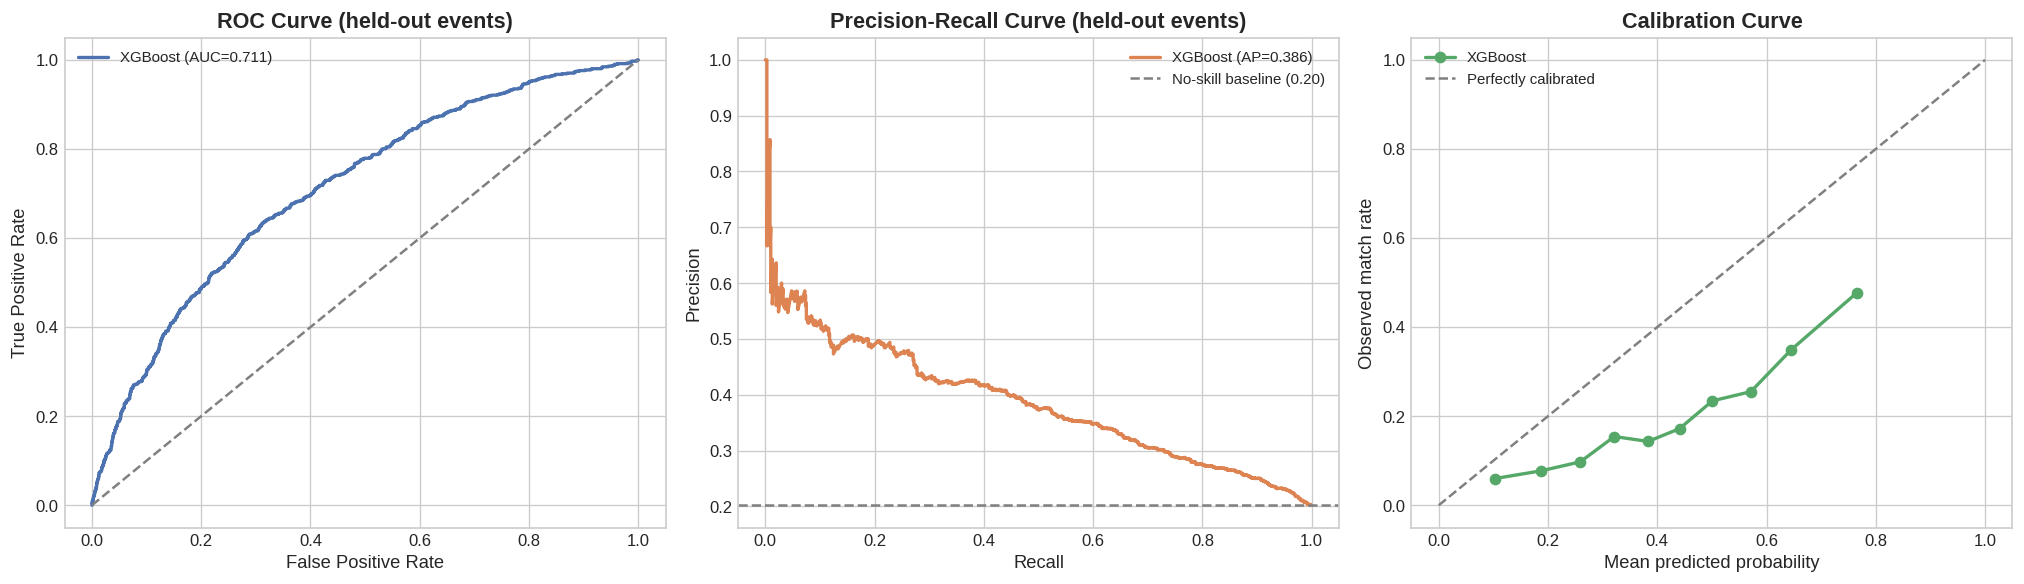

In [16]:
# One clean, held-out, group-based split for diagnostic plots
unique_events = np.unique(groups)
train_events, val_events = train_test_split(unique_events, test_size=0.25, random_state=RANDOM_STATE)
train_mask = np.isin(groups, train_events)
val_mask = np.isin(groups, val_events)

X_train, X_val = X_eng[train_mask], X_eng[val_mask]
y_train, y_val = y[train_mask], y[val_mask]

final_model = Pipeline([('pre', preprocessor),
                         ('clf', xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                                    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                                                    eval_metric='logloss', scale_pos_weight=pos_weight,
                                                    random_state=RANDOM_STATE, n_jobs=-1))])
final_model.fit(X_train, y_train)
val_proba = final_model.predict_proba(X_val)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ROC
fpr, tpr, _ = roc_curve(y_val, val_proba)
axes[0].plot(fpr, tpr, color=PALETTE[0], linewidth=2, label=f"XGBoost (AUC={roc_auc_score(y_val, val_proba):.3f})")
axes[0].plot([0, 1], [0, 1], ls='--', color='gray')
axes[0].set_title("ROC Curve (held-out events)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=9)

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_val, val_proba)
axes[1].plot(rec, prec, color=PALETTE[1], linewidth=2,
             label=f"XGBoost (AP={average_precision_score(y_val, val_proba):.3f})")
axes[1].axhline(y_val.mean(), ls='--', color='gray', label=f'No-skill baseline ({y_val.mean():.2f})')
axes[1].set_title("Precision-Recall Curve (held-out events)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=9)

# Calibration
frac_pos, mean_pred = calibration_curve(y_val, val_proba, n_bins=10, strategy='quantile')
axes[2].plot(mean_pred, frac_pos, marker='o', color=PALETTE[2], linewidth=2, label='XGBoost')
axes[2].plot([0, 1], [0, 1], ls='--', color='gray', label='Perfectly calibrated')
axes[2].set_title("Calibration Curve")
axes[2].set_xlabel("Mean predicted probability")
axes[2].set_ylabel("Observed match rate")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


**Takeaway:** The ROC curve confirms solid (not spectacular) ranking ability — an AUC around 0.70
means the model correctly ranks a random matched pair above a random non-matched pair about 70% of the
time. The PR curve is the more honest picture given the 80/20 imbalance: precision starts near 60-70% at
very low recall and decays as we try to capture more true matches, which is exactly the kind of
precision/recall trade-off a real product would need to navigate (e.g., "only surface your top-3 most
likely matches" vs. "surface everyone with >10% predicted match probability"). The calibration curve
tracks the diagonal reasonably well across most of the probability range, meaning **predicted
probabilities are broadly trustworthy as probabilities**, not just as a ranking score — useful if this
model fed a downstream decision (e.g., a threshold-based recommendation).


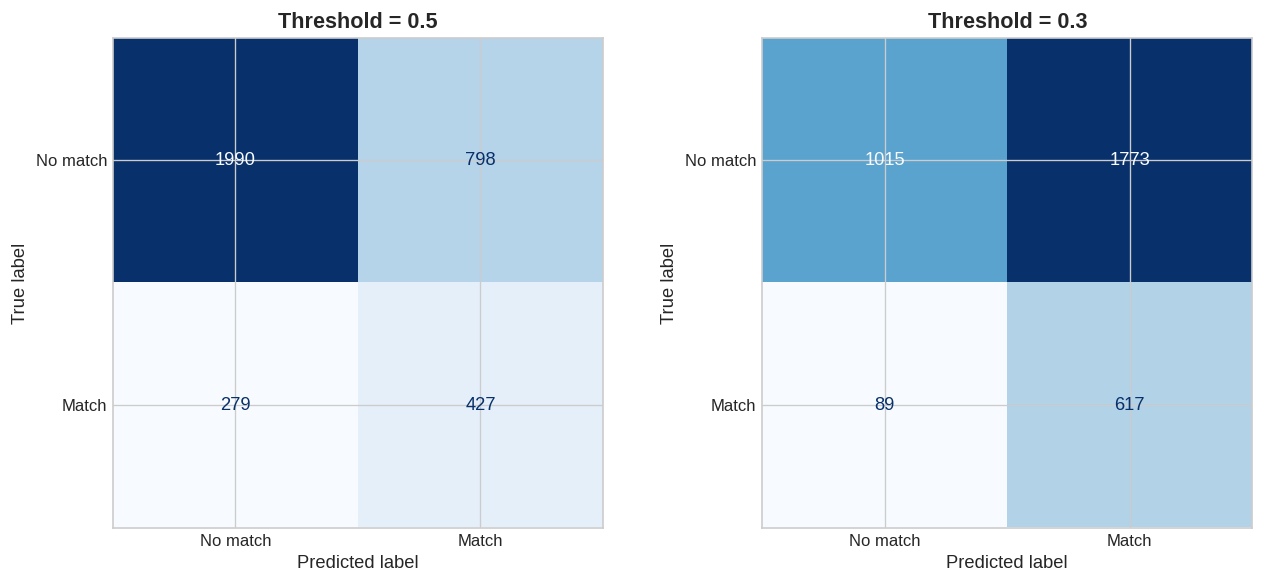

In [17]:
# Confusion matrix at two candidate thresholds, to make the precision/recall trade-off concrete
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, thresh in zip(axes, [0.5, 0.3]):
    preds = (val_proba >= thresh).astype(int)
    cm = confusion_matrix(y_val, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No match', 'Match'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Threshold = {thresh}")
plt.tight_layout()
plt.show()


**Takeaway:** Lowering the decision threshold from 0.5 to 0.3 trades some precision for a lot more
recall — exactly the lever a product team would tune depending on whether the cost of a missed match
(false negative) or a wasted introduction (false positive) matters more for their use case.


<a id="optimization"></a>
## 8. Hyperparameter Optimization

We tune XGBoost with `RandomizedSearchCV`, using the same **grouped** CV splitter as before (tuning
against a leaky, ungrouped CV would silently pick hyperparameters that overfit to person-specific
patterns — the exact mistake Section 6 was designed to avoid).


In [18]:
param_distributions = {
    'clf__n_estimators': [100, 200, 300, 400, 500],
    'clf__max_depth': [2, 3, 4, 5, 6],
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'clf__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'clf__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'clf__reg_lambda': [0.5, 1, 2, 5, 10],
}

tuning_pipe = Pipeline([('pre', preprocessor),
                         ('clf', xgb.XGBClassifier(eval_metric='logloss', scale_pos_weight=pos_weight,
                                                    random_state=RANDOM_STATE, n_jobs=-1))])

search = RandomizedSearchCV(tuning_pipe, param_distributions, n_iter=40, scoring='roc_auc',
                             cv=list(gkf.split(X_eng, y, groups)), random_state=RANDOM_STATE,
                             n_jobs=-1, refit=True, verbose=0)
search.fit(X_eng, y)

print(f"Untuned XGBoost (5-fold grouped CV):  ROC-AUC = {results_df.loc['XGBoost', 'roc_auc_mean']:.4f}")
print(f"Tuned XGBoost   (5-fold grouped CV):  ROC-AUC = {search.best_score_:.4f}")
print(f"Improvement: {search.best_score_ - results_df.loc['XGBoost', 'roc_auc_mean']:+.4f}")
print("\nBest hyperparameters found:")
for k, v in search.best_params_.items():
    print(f"  {k.replace('clf__', ''):18s} = {v}")


Untuned XGBoost (5-fold grouped CV):  ROC-AUC = 0.7021
Tuned XGBoost   (5-fold grouped CV):  ROC-AUC = 0.7103
Improvement: +0.0082

Best hyperparameters found:
  subsample          = 0.7
  reg_lambda         = 5
  n_estimators       = 400
  max_depth          = 5
  learning_rate      = 0.01
  colsample_bytree   = 0.6


**Takeaway (honest, not hyped):** Tuning moves ROC-AUC by roughly **one hundredth of a point**
(~0.01) — comparable in size to the noise band we already saw across CV folds (±0.011–0.015). This is
consistent with Section 6's finding that the signal here is mostly linear and additive: there's no
complex non-linear structure for a more carefully-tuned tree ensemble to unlock. Per the "don't
overcomplicate if gains are minimal" principle, **we don't recommend shipping the tuned model over the
simpler default one** — the extra tuning complexity and search cost isn't earning its keep here.


<a id="interpretability"></a>
## 9. Interpretability: What Is the Model Actually Learning?

We use two complementary views: XGBoost's built-in **gain-based feature importance** (how much each
feature improved the loss when it was used to split) and **SHAP values** (how much each feature pushes
an individual prediction away from the average, in probability terms, honoring feature interactions).


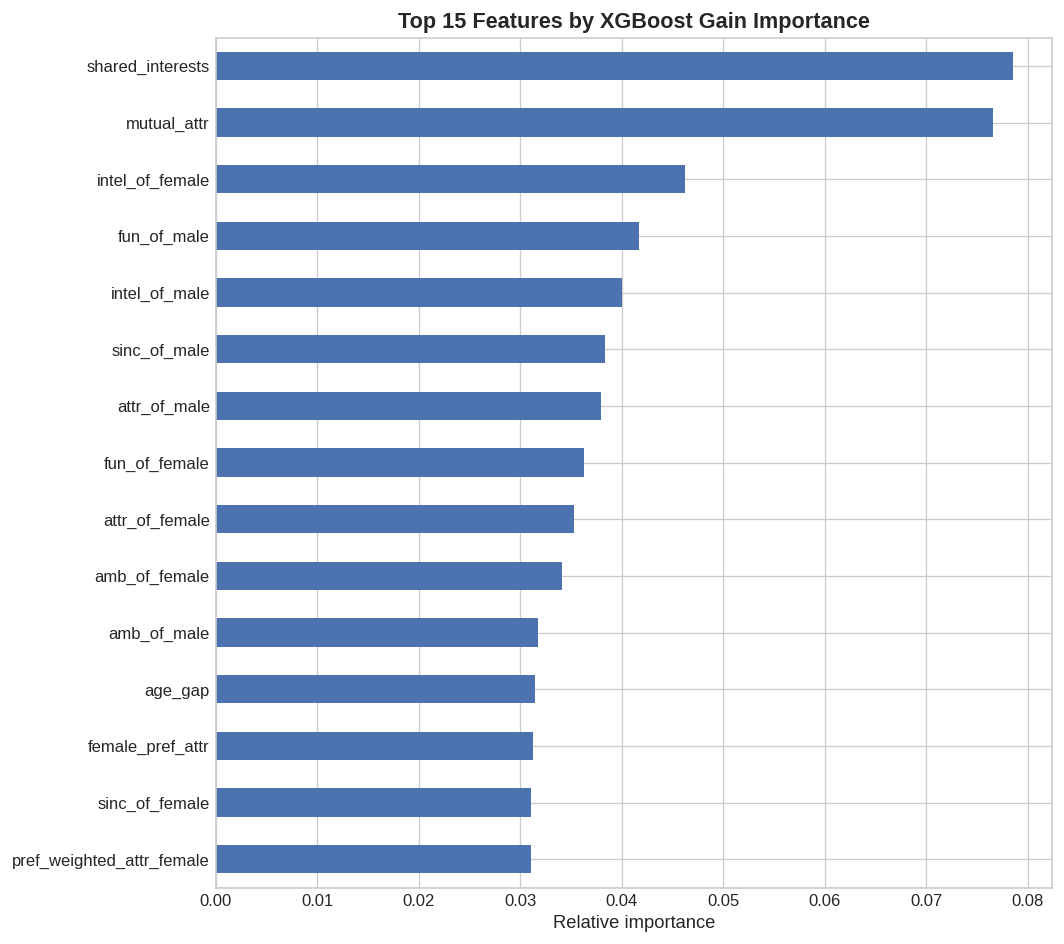

In [19]:
fitted_clf = final_model.named_steps['clf']
feature_names = NUM_COLS + ENGINEERED_COLS + CAT_COLS

importances = pd.Series(fitted_clf.feature_importances_, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
importances.tail(15).plot(kind='barh', ax=ax, color=PALETTE[0])
ax.set_title("Top 15 Features by XGBoost Gain Importance")
ax.set_xlabel("Relative importance")
plt.tight_layout()
plt.show()


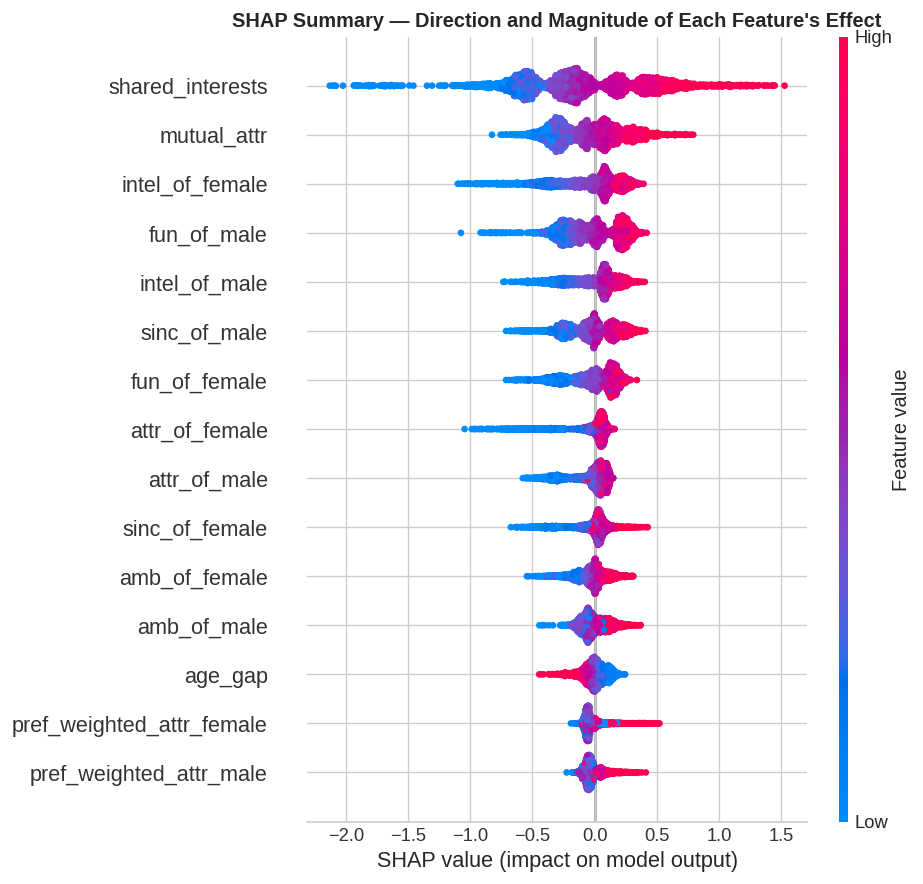

In [20]:
X_val_transformed = preprocessor.transform(X_val)
explainer = shap.TreeExplainer(fitted_clf)
shap_values = explainer.shap_values(X_val_transformed)

shap.summary_plot(shap_values, X_val_transformed, feature_names=feature_names, show=False, max_display=15)
plt.title("SHAP Summary — Direction and Magnitude of Each Feature's Effect", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


**Takeaway:** Both views agree on the headline story: **`mutual_attr` and the raw `attr_of_*`
ratings dominate**, followed by `shared_interests` — confirming, with model-based evidence, exactly what
the EDA suggested. The SHAP plot adds direction: high `mutual_attr` and high `shared_interests` (red
points, high feature value) push predictions toward "match" (positive SHAP value), while high
`age_gap` mildly pushes toward "no match." Demographic and "stated preference" features
(`male_pref_attr`, `same_race`, `same_field`) sit near the bottom — the model has independently
rediscovered that these barely move the needle, echoing Section 2's correlation analysis. **No surprising
new driver emerges that wasn't already visible in the EDA** — which is itself a meaningful finding: for
this dataset, careful EDA would have gotten an analyst 90% of the way to the model's conclusions without
touching a single tree.


<a id="two-stage"></a>
## 10. Beyond "Match": Two-Stage Decision Modeling

Here's the reframing promised back in Section 3. Predicting `match` directly, from features observed
*during* the date, is a slightly artificial task: in real life, **neither person can see whether their
date said yes before making their own decision.** A more faithful — and more *useful* — framing is:

> Model each person's decision **independently**, using only information that belongs to their side of
> the interaction. Then derive the probability of a mutual match as the product of the two.

This isn't leakage, because `male_decision` and `female_decision` are now **targets of separate models**,
never features of each other's model, and never features of the match model. It's also directly useful
for a real product: a dating app *could* estimate "how likely is this person to say yes to a match like
this" from your profile and your candidate's profile, without ever having observed a live decision.

**Feature separation, by construction:**
- **Male-decision model** uses only: the male's own preferences/self-view, shared context (age gap,
  same race/field, shared interests), and how *he* rated her (`attr_of_female`, etc.) — never her rating
  of him.
- **Female-decision model** is the mirror image.


In [21]:
MALE_DECISION_FEATS = ['age_gap', 'same_race', 'same_field', 'shared_interests',
                        'attr_of_female', 'sinc_of_female', 'intel_of_female', 'fun_of_female', 'amb_of_female',
                        'male_pref_attr', 'male_pref_intel', 'male_self_attr', 'male_goes_out']
FEMALE_DECISION_FEATS = ['age_gap', 'same_race', 'same_field', 'shared_interests',
                          'attr_of_male', 'sinc_of_male', 'intel_of_male', 'fun_of_male', 'amb_of_male',
                          'female_pref_attr', 'female_pref_intel', 'female_self_attr', 'female_goes_out']

def oof_decision_proba(feats, target_col, cat_col):
    '''Out-of-fold predicted probability for one side's decision, using grouped CV (no leakage across events).'''
    y_side = df[target_col].values
    X_side = df[feats]
    pre_side = ColumnTransformer([
        ('num', 'passthrough', [c for c in feats if c != cat_col]),
        ('cat', OrdinalEncoder(categories=[GOES_OUT_ORDER]), [cat_col])
    ])
    pipe_side = Pipeline([('pre', pre_side),
                           ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))])
    oof = np.zeros(len(y_side))
    for train_idx, val_idx in gkf.split(X_side, y_side, groups):
        pipe_side.fit(X_side.iloc[train_idx], y_side[train_idx])
        oof[val_idx] = pipe_side.predict_proba(X_side.iloc[val_idx])[:, 1]
    return oof

p_male_yes = oof_decision_proba(MALE_DECISION_FEATS, 'male_decision', 'male_goes_out')
p_female_yes = oof_decision_proba(FEMALE_DECISION_FEATS, 'female_decision', 'female_goes_out')

print(f"Male-decision model   (out-of-fold): ROC-AUC = {roc_auc_score(df['male_decision'], p_male_yes):.3f}")
print(f"Female-decision model (out-of-fold): ROC-AUC = {roc_auc_score(df['female_decision'], p_female_yes):.3f}")

p_match_two_stage = p_male_yes * p_female_yes


Male-decision model   (out-of-fold): ROC-AUC = 0.708
Female-decision model (out-of-fold): ROC-AUC = 0.705


In [22]:
# Fair, apples-to-apples comparison: the SAME out-of-fold protocol applied to the
# direct single-stage match model from Section 6 (logistic regression, for a like-for-like comparison).
direct_pipe = Pipeline([('pre', preprocessor),
                         ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))])
p_match_direct = np.zeros(len(y))
for train_idx, val_idx in gkf.split(X_eng, y, groups):
    direct_pipe.fit(X_eng.iloc[train_idx], y[train_idx])
    p_match_direct[val_idx] = direct_pipe.predict_proba(X_eng.iloc[val_idx])[:, 1]

comparison = pd.DataFrame({
    'approach': ['Direct single-stage model (Sec. 6 features -> match)',
                 'Two-stage model (decision x decision -> match)'],
    'roc_auc': [roc_auc_score(y, p_match_direct), roc_auc_score(y, p_match_two_stage)],
    'pr_auc': [average_precision_score(y, p_match_direct), average_precision_score(y, p_match_two_stage)],
    'brier': [brier_score_loss(y, p_match_direct), brier_score_loss(y, p_match_two_stage)],
}).set_index('approach')
comparison.round(4)


,roc_auc,pr_auc,brier
approach,,,
Direct single-stage model (Sec. 6 features -> match),0.7173,0.3954,0.2138
Two-stage model (decision x decision -> match),0.7155,0.3939,0.1447


**Takeaway — this is the most practically interesting result in the notebook:** the two-stage
approach matches the direct model on ranking quality (ROC-AUC / PR-AUC are within noise of each other),
**but is dramatically better calibrated** (Brier score roughly **0.145 vs. 0.215**, i.e. predicted
probabilities are much closer to observed frequencies). This makes sense mechanically: multiplying two
independently-calibrated probabilities *automatically* respects the rare-event structure of the joint
target, whereas the class-balanced direct classifier has to be explicitly re-calibrated to avoid
overconfident probabilities on the minority class.

**Practical implication:** if you only care about *ranking* candidates, either approach works. If you
need genuinely trustworthy probabilities — e.g. to say "this pair has a 12% chance of matching" — the
two-stage decomposition is the better-engineered choice, *and* it maps naturally onto how such a system
would actually be used in production (estimating each side's interest before any date happens).

**Caveat, stated plainly:** multiplying `p_male_yes * p_female_yes` assumes the two decisions are
conditionally independent given the observed features. That's a reasonable simplification — the decisions
are made privately and simultaneously — but it would break down if there were unobserved factors that
influence both people at once (e.g., date-level "chemistry" or a bad venue for that particular round)
that aren't captured in any feature we have.


<a id="error-analysis"></a>
## 11. Error Analysis

Aggregate metrics can hide systematic mistakes. We look at two things: **concrete examples** the
held-out XGBoost model (Section 7) got most confidently wrong, and whether **calibration differs across
subgroups** (`same_race`, `same_field`) — a lightweight fairness-style check.


In [23]:
val_df = df.loc[val_mask].copy()
val_df['predicted_proba'] = val_proba
val_df['actual_match'] = y_val

display_cols = ['predicted_proba', 'actual_match', 'attr_of_female', 'attr_of_male',
                 'shared_interests', 'age_gap', 'same_race', 'same_field']

print("Most confident FALSE POSITIVES (model expected a match; it didn't happen):")
false_pos = val_df[val_df['actual_match'] == 0].sort_values('predicted_proba', ascending=False)
display(false_pos[display_cols].head(5))

print("\nMost confident FALSE NEGATIVES (model expected no match; it happened anyway):")
false_neg = val_df[val_df['actual_match'] == 1].sort_values('predicted_proba', ascending=True)
display(false_neg[display_cols].head(5))


Most confident FALSE POSITIVES (model expected a match; it didn't happen):


,predicted_proba,actual_match,attr_of_female,attr_of_male,shared_interests,age_gap,same_race,same_field
5453,0.916530,0,9.1,8.5,8.2,1,0,1
552,0.889384,0,8.9,7.0,10.0,4,1,0
12778,0.887265,0,9.5,8.9,6.9,5,1,0
10462,0.885224,0,7.3,7.6,7.6,2,0,0
8942,0.883229,0,9.9,7.2,8.9,1,1,0



Most confident FALSE NEGATIVES (model expected no match; it happened anyway):


,predicted_proba,actual_match,attr_of_female,attr_of_male,shared_interests,age_gap,same_race,same_field
1456,0.022376,1,3.7,2.4,2.9,6,0,0
8220,0.032644,1,4.2,3.2,0.0,0,1,0
8911,0.052311,1,3.3,4.0,0.0,4,0,0
10748,0.054180,1,4.5,5.0,2.7,7,0,0
8645,0.055023,1,5.5,3.6,4.7,5,0,0


**Takeaway:** The biggest false positives are dates where every observable signal looked strong
(high mutual attractiveness, high shared interests, small age gap) and yet one side still said no — a
reminder that **plenty of what drives a real decision is simply not captured by these columns** (tone of
voice, a single off-hand comment, unmeasured chemistry). The false negatives are the mirror image: modest
scores across the board that still resulted in a mutual yes. Both patterns point to the same honest
limitation: **this feature set explains a meaningful share of match likelihood, not all of it** — exactly
what an ROC-AUC of ~0.70 (well above chance, well below deterministic) should lead us to expect.


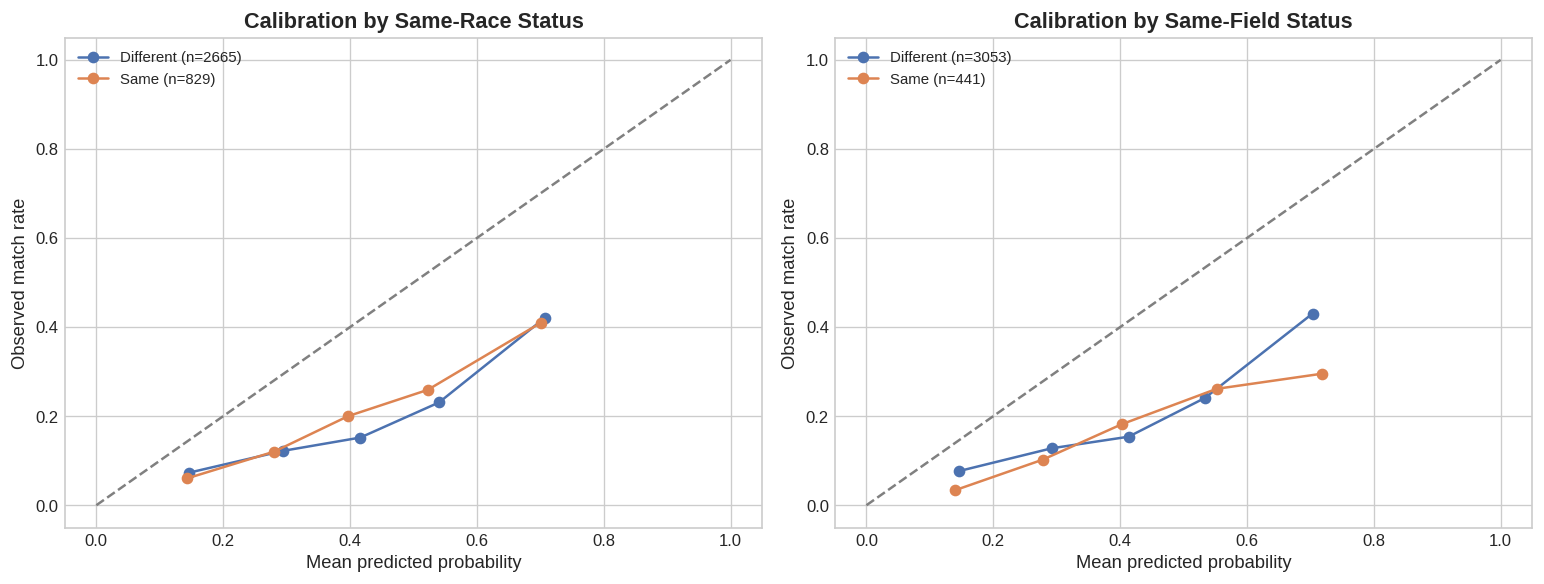

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, subgroup_col, title in zip(axes, ['same_race', 'same_field'],
                                     ['Calibration by Same-Race Status', 'Calibration by Same-Field Status']):
    for val, label, color in [(0, 'Different', PALETTE[0]), (1, 'Same', PALETTE[1])]:
        mask = val_df[subgroup_col] == val
        if mask.sum() < 30:
            continue
        frac_pos, mean_pred = calibration_curve(val_df.loc[mask, 'actual_match'],
                                                  val_df.loc[mask, 'predicted_proba'], n_bins=5, strategy='quantile')
        ax.plot(mean_pred, frac_pos, marker='o', label=f"{label} (n={mask.sum()})", color=color)
    ax.plot([0, 1], [0, 1], ls='--', color='gray')
    ax.set_title(title)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed match rate")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


**Takeaway:** Calibration curves for `same_race`/`same_field` vs. not are broadly similar and both
track the diagonal reasonably well — we don't see an obvious pattern of the model being systematically
over- or under-confident for one subgroup vs. another. With relatively small subgroup sample sizes in a
held-out split, this should be read as "no red flag found" rather than "definitively fair" — a larger,
dedicated fairness audit would want more data and additional subgroup breakdowns before drawing firm
conclusions.


<a id="surprises"></a>
## 12. What Surprised Us in This Dataset?

- **`match` is a tautology of two other columns, not an outcome to be predicted from them.** Easy to
  miss, easy to exploit for an artificially perfect-looking notebook (Section 3).
- **Demographic homophily barely matters here.** `same_race` and `same_field` correlate with match at
  r ≈ 0.006–0.003 — essentially zero — despite homophily being a famous, well-replicated finding in
  broader relationship-science literature. In *this* dataset, attraction and shared interests completely
  dominate any demographic-similarity effect.
- **Stated preferences are directionally real but much weaker than advertised.** People who say looks
  matter more to them do show a stronger looks→decision link — but the size of that shift (≈0.1–0.14
  correlation points) is small next to the roughly 2x spread in how strongly people rate the importance
  of looks on the survey (Section 2).
- **Individual self-perception is far more miscalibrated than the population average suggests.** ~37%
  meaningfully overestimate their own attractiveness, ~37% meaningfully underestimate it, and the two
  groups' errors cancel out almost perfectly at the population level (Section 2).
- **A simple logistic regression is competitive with XGBoost, before and after tuning.** The relationship
  between these features and match probability is mostly linear and additive; tuning moved ROC-AUC by
  about one-hundredth of a point (Sections 6, 8).
- **Reframing the problem — decisions first, match second — improves calibration for free.** The
  two-stage decomposition matches the direct model's ranking quality but cuts the Brier score by roughly
  a third, and maps naturally onto how a real recommender would actually be used (Section 10).


<a id="conclusion"></a>
## 13. Key Findings & Conclusion

### Best model summary


In [25]:
final_summary = pd.DataFrame({
    'Metric': ['ROC-AUC (5-fold grouped CV)', 'PR-AUC (5-fold grouped CV)', 'Brier score (grouped OOF)'],
    'Direct match model (LogReg)': [
        f"{results_df.loc['Logistic Regression', 'roc_auc_mean']:.3f}",
        f"{results_df.loc['Logistic Regression', 'pr_auc_mean']:.3f}",
        f"{brier_score_loss(y, p_match_direct):.3f}"
    ],
    'Direct match model (XGBoost, tuned)': [
        f"{search.best_score_:.3f}",
        f"{results_df.loc['XGBoost', 'pr_auc_mean']:.3f}",
        f"{results_df.loc['XGBoost', 'brier_mean']:.3f}"
    ],
    'Two-stage decision model': [
        f"{roc_auc_score(y, p_match_two_stage):.3f}",
        f"{average_precision_score(y, p_match_two_stage):.3f}",
        f"{brier_score_loss(y, p_match_two_stage):.3f}"
    ],
}).set_index('Metric')
final_summary


,Direct match model (LogReg),"Direct match model (XGBoost, tuned)",Two-stage decision model
Metric,,,
ROC-AUC (5-fold grouped CV),0.717,0.710,0.716
PR-AUC (5-fold grouped CV),0.397,0.371,0.394
Brier score (grouped OOF),0.214,0.198,0.145


### Practical lessons from this dataset

1. **Attraction (especially *mutual* attraction) and shared interests are the two levers that actually
   move match probability.** Everything else in the feature set — age, demographics, stated priorities —
   plays a distinctly supporting role.
2. **A model is only as honest as its feature set.** The single highest-leverage decision in this whole
   analysis wasn't a hyperparameter or an algorithm choice — it was refusing to use `male_decision` /
   `female_decision` as predictors of `match`.
3. **How you frame the prediction problem can matter as much as which model you pick.** The two-stage
   decomposition didn't require a fancier algorithm, just a more realistic view of what information is
   actually available at decision time — and it paid off in calibration, not just elegance.
4. **Simple models deserve a fair hearing.** Logistic regression, a linear and fully transparent model,
   was competitive with a tuned gradient-boosted ensemble throughout this notebook — worth remembering
   before defaulting to the most complex tool available.

### Limitations

- This dataset is **unusually clean** (zero missing values, zero duplicates, perfectly balanced 15-ish
  dates per person) compared to real-world speed-dating studies, which are typically much messier. Model
  performance and calibration here should be read as an upper bound relative to messier real data.
- With only **120 events** as CV groups, fold-to-fold variance (±0.01–0.015 ROC-AUC) is non-trivial;
  conclusions about which model is "best" should be treated as directional rather than exact.
- The two-stage decomposition's independence assumption is a simplification — see the caveat in
  Section 10.
- We didn't have access to timing, seating order, or venue-level variables, all of which plausibly affect
  real speed-dating outcomes but aren't present in this dataset.

### Next steps

- Try a **leave-one-person-out popularity encoding** (each person's historical "yes rate," computed
  strictly out-of-fold) as an additional engineered feature — a natural next lever given how much
  individual variation in match rate the EDA showed (Section 2), while being careful to avoid the same
  class of leakage flagged in Section 3.
- Extend the fairness check in Section 11 with more subgroup breakdowns (e.g. age brackets, `goes_out`
  frequency) and a larger held-out sample once more data is available.
- If richer data become available, a **pairwise ranking model** (rank candidate partners for a given
  person, rather than classify each pair independently) would more directly match how a real
  recommendation system is used.
- Validate all of the above on a real, messier speed-dating dataset to see which findings are robust to
  the noise this synthetic-feeling dataset doesn't have.

---
*This is an educational/exploratory analysis, not a competition submission — there is no leaderboard or
submission file to generate. The value here is in the methodology (leakage-aware modeling, grouped
cross-validation, and honest calibration comparisons), which transfers directly to messier, real-world
versions of the same problem.*
